# VRP con algoritmo genético

En este notebook cargamos los 4 escenarios calculados en `grafo.ipynb` (las matrices de tiempo entre el depósito y las entregas, con las velocidades predichas) y los resolvemos con el Algoritmo Genético.

El objetivo es optimizar el makespan, es decir, el tiempo que se tarda en hacer todas las entregas. Los vehículos salen todos a la vez y en paralelo, por lo tanto, el vehículo que más tarda es lo que determina cuándo termina el reparto completo. También calculamos el tiempo total como métrica secundaria.

Detalles del Algotirmo Genético:

- **Representación (cromosoma)**: es una permutación de las entregas (el orden en el que se hacen). Para decidir qué vehículo lleva cada entrega, creamos una función de reparto (`split`) que recorre la permutación y va asignando entregas al vehículo actual hasta que se le acaba la capacidad o el tiempo máximo, entonces pasa al siguiente.

- **Fitness:** el makespan. Optimizamos por el tiempo del vehículo que más tarda. Si una permutación necesita más vehículos de los disponibles, le penalizamos para que la evolución la descarte. También calculamos el tiempo total como información adicional.

- **Operadores**: usamos la selección por torneo, cruce OX (Order Crossover), mutación por intercambio, y elitismo.

## 0. Importación de paquetes y carga de datos necesarios

In [13]:
!pip install osmnx --quiet

In [14]:
import pickle
import random as rnd
import numpy as np
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx

In [15]:
from google.colab import drive
drive.mount('/content/drive')

data_clean = "/content/drive/MyDrive/TFM/data_clean"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# cargamos escenarios
with open(f"{data_clean}/escenarios_vrp.pkl", "rb") as f:
    paquete = pickle.load(f)

puntos_elegidos = paquete["puntos_elegidos"]
deposito = paquete["deposito"]
entregas = paquete["entregas"]
n_vehiculos = paquete["n_vehiculos"]
max_entregas_por_vehiculo = paquete["max_entregas_por_vehiculo"]
matrices = paquete["matrices"]

tiempo_max_vehiculo = 10800 # 3 horas
entregas_idx = list(range(1, len(puntos_elegidos)))  # índices 1..n; el 0 es el depósito

print(f"Escenarios disponibles: {list(matrices.keys())}")
print(f"Entregas: {len(entregas_idx)}, vehículos: {n_vehiculos}")

Escenarios disponibles: ['historico_lgbm', 'historico_gcn', 'vivo_lgbm', 'vivo_gcn']
Entregas: 25, vehículos: 4


## 1. Decodificación: de permutación a rutas

Recorremos la permutación y la repartimos entre los vehículos, teniendo en cuenta la capacidad y tiempo máximo. Si se necesitaran más vehículos de los disponibles, `fitness_individuo` devuelve `inf` para que la solución se descarte en la evolución.

In [17]:
def split_en_rutas_ga(permutacion, matriz_tiempo, deposito_index, max_entregas_por_vehiculo, tiempo_max_vehiculo, n_vehiculos):
    rutas = []
    ruta_actual = [deposito_index]
    tiempo_actual = 0

    for punto in permutacion:
        es_ultimo_vehiculo_disponible = (len(rutas) == n_vehiculos - 1)
        tiempo_extra = matriz_tiempo[ruta_actual[-1]][punto]
        tiempo_vuelta = matriz_tiempo[punto][deposito_index]

        cabe_en_capacidad = (len(ruta_actual) - 1) < max_entregas_por_vehiculo
        cabe_en_tiempo = (tiempo_actual + tiempo_extra + tiempo_vuelta) <= tiempo_max_vehiculo

        # si es el último vehículo disponible, no podemos abrir uno nuevo aunque no quepa:
        # forzamos la entrega en este, igual que tendría que hacer un reparto real
        if es_ultimo_vehiculo_disponible or (cabe_en_capacidad and cabe_en_tiempo):
            ruta_actual.append(punto)
            tiempo_actual += tiempo_extra
        else:
            ruta_actual.append(deposito_index)
            rutas.append(ruta_actual)
            ruta_actual = [deposito_index, punto]
            tiempo_actual = matriz_tiempo[deposito_index][punto]

    ruta_actual.append(deposito_index)
    rutas.append(ruta_actual)
    return rutas


def fitness_individuo(permutacion, matriz_tiempo, deposito_index, max_entregas_por_vehiculo, tiempo_max_vehiculo, n_vehiculos):
    """Esta función crea el makespan de la solución."""
    rutas = split_en_rutas_ga(permutacion, matriz_tiempo, deposito_index, max_entregas_por_vehiculo, tiempo_max_vehiculo, n_vehiculos)

    tiempos_por_ruta = [
        sum(matriz_tiempo[ruta[i]][ruta[i+1]] for i in range(len(ruta) - 1))
        for ruta in rutas
    ]
    makespan = max(tiempos_por_ruta)

    return makespan, rutas

## 2. Operadores genéticos

In [18]:
def crear_individuo(entregas_idx):
    ind = entregas_idx.copy()
    rnd.shuffle(ind)
    return ind


def cruce_ox(padre1, padre2):
    n = len(padre1)
    i, j = sorted(rnd.sample(range(n), 2))

    hijo = [None] * n
    hijo[i:j] = padre1[i:j]

    genes_usados = set(hijo[i:j])
    resto_padre2 = [g for g in padre2 if g not in genes_usados]

    pos = 0
    for k in range(n):
        if hijo[k] is None:
            hijo[k] = resto_padre2[pos]
            pos += 1
    return hijo


def mutacion_swap(individuo, prob_mutacion):
    individuo = individuo.copy()
    if rnd.random() < prob_mutacion:
        i, j = rnd.sample(range(len(individuo)), 2)
        individuo[i], individuo[j] = individuo[j], individuo[i]
    return individuo


def seleccion_torneo(poblacion, fitnesses, k=3):
    candidatos = rnd.sample(range(len(poblacion)), k)
    mejor = min(candidatos, key=lambda idx: fitnesses[idx])
    return poblacion[mejor]

## 3. Bucle principal

In [19]:
def algoritmo_genetico(matriz_tiempo, deposito_index, entregas_idx, n_vehiculos,
                        max_entregas_por_vehiculo, tiempo_max_vehiculo=tiempo_max_vehiculo,
                        tam_poblacion=100, n_generaciones=200, prob_mutacion=0.15, elitismo=4,
                        verbose=True):

    poblacion = [crear_individuo(entregas_idx) for _ in range(tam_poblacion)]
    mejor_fitness_historico = float("inf")
    mejor_individuo_historico = None
    historial = []

    for gen in range(n_generaciones):
        resultados = [
            fitness_individuo(ind, matriz_tiempo, deposito_index, max_entregas_por_vehiculo, tiempo_max_vehiculo, n_vehiculos)
            for ind in poblacion
        ]
        fitnesses = [r[0] for r in resultados]

        mejor_gen_idx = min(range(len(poblacion)), key=lambda i: fitnesses[i])
        if fitnesses[mejor_gen_idx] < mejor_fitness_historico:
            mejor_fitness_historico = fitnesses[mejor_gen_idx]
            mejor_individuo_historico = poblacion[mejor_gen_idx].copy()

        historial.append(mejor_fitness_historico)

        indices_ordenados = sorted(range(len(poblacion)), key=lambda i: fitnesses[i])
        nueva_poblacion = [poblacion[i].copy() for i in indices_ordenados[:elitismo]]

        while len(nueva_poblacion) < tam_poblacion:
            padre1 = seleccion_torneo(poblacion, fitnesses)
            padre2 = seleccion_torneo(poblacion, fitnesses)
            hijo = cruce_ox(padre1, padre2)
            hijo = mutacion_swap(hijo, prob_mutacion)
            nueva_poblacion.append(hijo)

        poblacion = nueva_poblacion

        if verbose and (gen % 40 == 0 or gen == n_generaciones - 1):
            print(f"  Generación {gen}: mejor makespan = {mejor_fitness_historico/60:.1f} min")

    return mejor_individuo_historico, mejor_fitness_historico, historial

## 4. Resolvemos los escenarios

In [20]:
resultados_genetico = {}
historiales = {}

for nombre_escenario, matriz in matrices.items():
    print(f"\n{nombre_escenario}")
    print("="*30)

    mejor_individuo, mejor_fitness, historial = algoritmo_genetico(
        matriz, deposito_index=0, entregas_idx=entregas_idx,
        n_vehiculos=n_vehiculos, max_entregas_por_vehiculo=max_entregas_por_vehiculo
    )
    historiales[nombre_escenario] = historial

    rutas_idx = split_en_rutas_ga(mejor_individuo, matriz, 0, max_entregas_por_vehiculo, tiempo_max_vehiculo, n_vehiculos)
    rutas = []
    tiempo_total = 0
    for i, ruta in enumerate(rutas_idx):
        tiempo_ruta = sum(matriz[ruta[k]][ruta[k+1]] for k in range(len(ruta) - 1))
        rutas.append({
            "vehiculo": i,
            "puntos": [puntos_elegidos[idx] for idx in ruta],
            "n_entregas": len(ruta) - 2,
            "tiempo_segundos": tiempo_ruta,
            "tiempo_minutos": round(tiempo_ruta / 60, 1),
        })
        tiempo_total += tiempo_ruta

    makespan = max(r["tiempo_segundos"] for r in rutas)

    for r in rutas:
        print(f"  Vehículo {r['vehiculo']}: {r['n_entregas']} entregas, {r['tiempo_minutos']} min")
    print(f"  Vehículos usados: {len(rutas)} de {n_vehiculos}")
    print(f"  Makespan: {round(makespan/60, 1)} min")
    print(f"  Tiempo total (informativo): {round(tiempo_total/60, 1)} min")

    resultados_genetico[nombre_escenario] = {
        "rutas": rutas,
        "tiempo_total": tiempo_total,
        "makespan": makespan,
        "n_vehiculos_usados": len(rutas),
    }


historico_lgbm
  Generación 0: mejor makespan = 298.6 min
  Generación 40: mejor makespan = 162.5 min
  Generación 80: mejor makespan = 159.9 min
  Generación 120: mejor makespan = 158.7 min
  Generación 160: mejor makespan = 158.6 min
  Generación 199: mejor makespan = 158.6 min
  Vehículo 0: 4 entregas, 156.2 min
  Vehículo 1: 7 entregas, 153.3 min
  Vehículo 2: 8 entregas, 158.1 min
  Vehículo 3: 6 entregas, 158.6 min
  Vehículos usados: 4 de 4
  Makespan: 158.6 min
  Tiempo total (informativo): 626.2 min

historico_gcn
  Generación 0: mejor makespan = 347.4 min
  Generación 40: mejor makespan = 156.9 min
  Generación 80: mejor makespan = 154.6 min
  Generación 120: mejor makespan = 154.6 min
  Generación 160: mejor makespan = 154.6 min
  Generación 199: mejor makespan = 154.6 min
  Vehículo 0: 8 entregas, 148.7 min
  Vehículo 1: 8 entregas, 150.3 min
  Vehículo 2: 6 entregas, 151.5 min
  Vehículo 3: 3 entregas, 154.6 min
  Vehículos usados: 4 de 4
  Makespan: 154.6 min
  Tiempo to

## 5. Evolución del fitness por escenario

Visualizamos cómo baja el mejor makespan encontrado, generación a generación, en cada uno de los 4 escenarios.

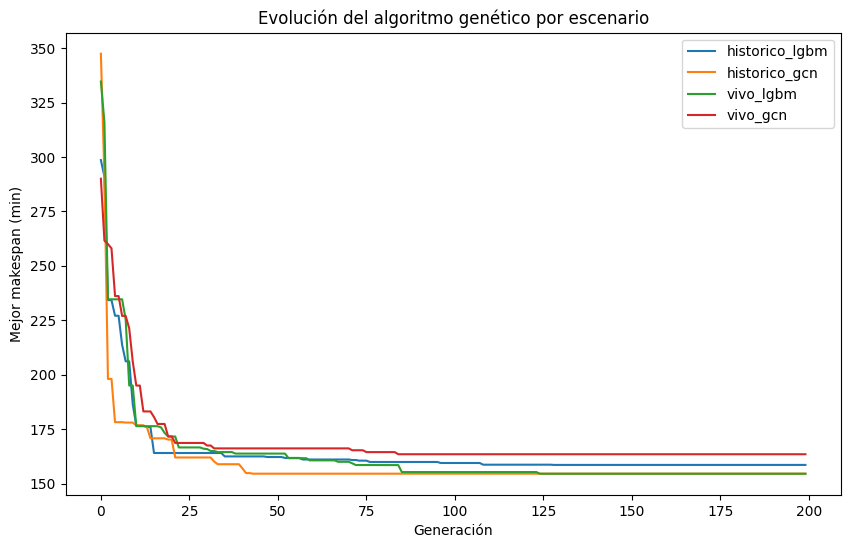

In [21]:
plt.figure(figsize=(10, 6))
for nombre_escenario, historial in historiales.items():
    plt.plot(np.array(historial) / 60, label=nombre_escenario)

plt.xlabel("Generación")
plt.ylabel("Mejor makespan (min)")
plt.title("Evolución del algoritmo genético por escenario")
plt.legend()
plt.show()

Vemos que las 4 curvas convergen dentro de las primeras 30-50 generaciones, y luego se estabilizan, lo que significa que el algoritmo encuentra rápido una buena solución y el resto de generaciones aportan pequeñas mejoras.

Los cuatro escenarios convergen a un makespan de 155-165 minutos, lo que significa que, para este conjunto de entregas, la calidad de la ruta encontrada por el genético es bastante consistente independientemente de las condiciones de tráfico o el modelo usado. `vivo_gcn` es el que converge más alto (\~163 min), un poco peor que los otros tres, mientras que `historico_gcn` y `vivo_lgbm` son los que mejor resultado dan (\~155 min).

## 6. Guardamos los resultados

Finalmente guardamos los resultados para luego cargarlos en `grafo.ipynb`, en el apartado de comparativa final.

In [22]:
with open(f"{data_clean}/resultados_genetico.pkl", "wb") as f:
    pickle.dump(resultados_genetico, f)

## 7. Visualización de rutas

Vamos a dibujar las rutas de cada escenario sobre el mapa.

In [23]:
# grafo G con los pesos de los escenarios

G = ox.load_graphml(
    filepath=f"{data_clean}/chicago_graph_4_escenarios.graphml",
    edge_dtypes={
        "travel_time_hist_lgbm": float,
        "travel_time_hist_gcn": float,
        "travel_time_vivo_lgbm": float,
        "travel_time_vivo_gcn": float,
    }
)

nombre_peso = {
    "historico_lgbm": "travel_time_hist_lgbm",
    "historico_gcn": "travel_time_hist_gcn",
    "vivo_lgbm": "travel_time_vivo_lgbm",
    "vivo_gcn": "travel_time_vivo_gcn",
}

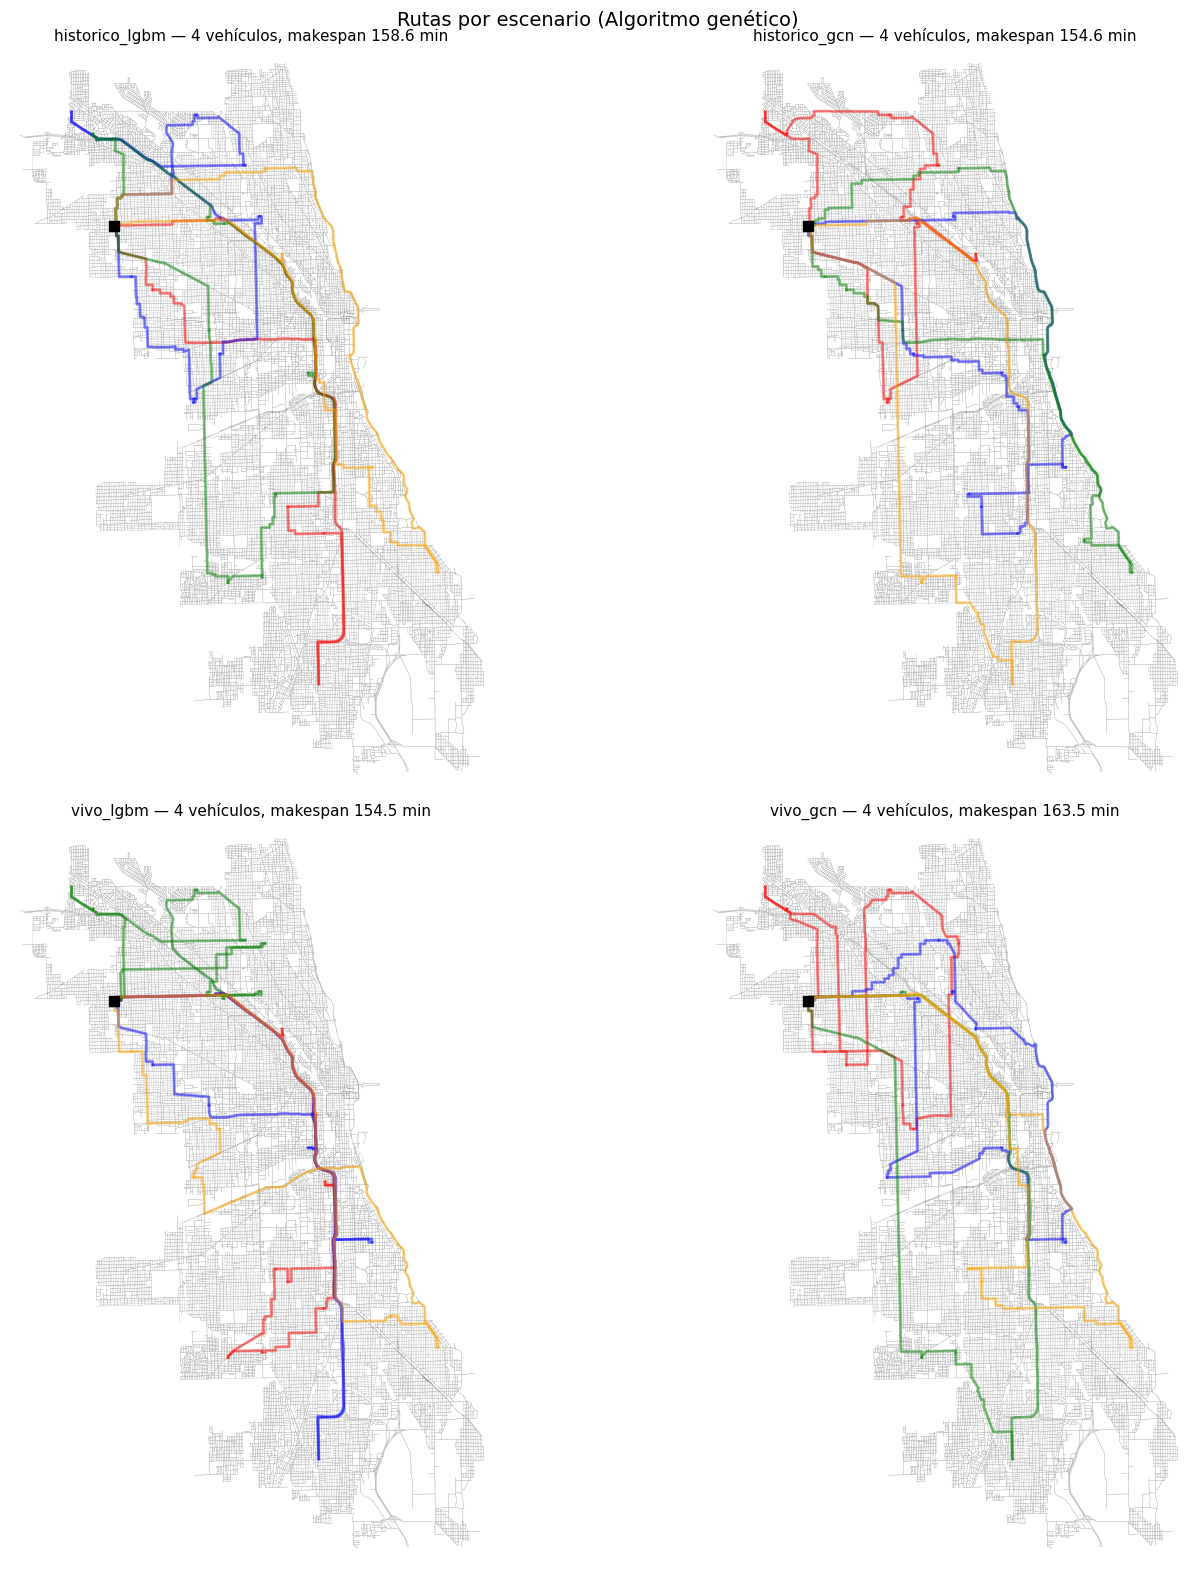

In [24]:
def dibujar_escenario(ax, G, weight_attr, rutas, deposito, entregas, titulo):
    ox.plot_graph(G, ax=ax, show=False, close=False, node_size=0, edge_linewidth=0.15, bgcolor="white")

    colores = ["red", "blue", "green", "orange", "purple", "brown", "pink", "cyan"]
    for i, r in enumerate(rutas):
        color = colores[i % len(colores)]
        for a, b in zip(r["puntos"][:-1], r["puntos"][1:]):
            camino = nx.shortest_path(G, a, b, weight=weight_attr)
            ox.plot_graph_route(G, camino, ax=ax, route_color=color, route_linewidth=2,
                                 show=False, close=False, orig_dest_size=0)

    x_dep, y_dep = G.nodes[deposito]["x"], G.nodes[deposito]["y"]
    ax.scatter(x_dep, y_dep, c="black", s=60, marker="s", zorder=5)
    ax.set_title(titulo, fontsize=11)


fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, (nombre_escenario, weight_attr) in zip(axes, nombre_peso.items()):
    r = resultados_genetico[nombre_escenario]
    titulo = f"{nombre_escenario} — {r['n_vehiculos_usados']} vehículos, makespan {round(r['makespan']/60,1)} min"
    dibujar_escenario(ax, G, weight_attr, r["rutas"], deposito, entregas, titulo)

plt.suptitle("Rutas por escenario (Algoritmo genético)", fontsize=14)
plt.tight_layout()
plt.show()